#GROUP3 - FASION MNIST ANALYSIS
#MEMBERS:
###Campbell, Peyton
###Mare, Pruthvi
###Ngo, William
###Trinh, Dinh Lam

###Import libraries

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

###Import dataset

In [4]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

#normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

#print dataset shape
print(f"Train set shape: {x_train.shape}, Labels: {y_train.shape}")
print(f"Test set shape: {x_test.shape}, Labels: {y_test.shape}")


Train set shape: (60000, 28, 28), Labels: (60000,)
Test set shape: (10000, 28, 28), Labels: (10000,)


###Plot some samples

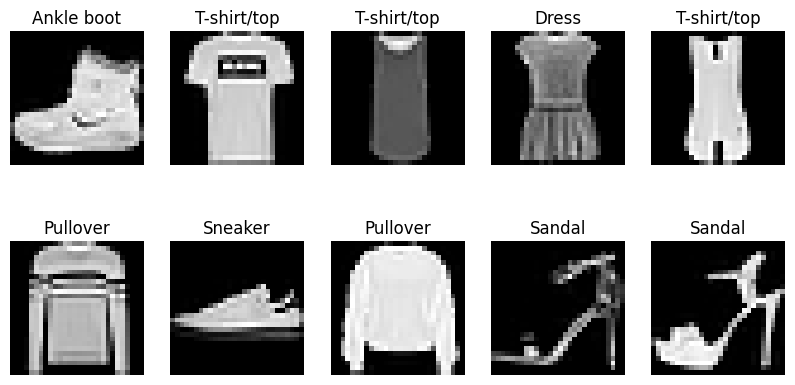

In [5]:
# Class labels
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Plot first few images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()


###First model (1 hidden layer ANN)

In [6]:
#model-1 with 1 hidden layer of sigmoid
model1 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(32, activation='sigmoid'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
#define optimizer
model1.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

####Training 1st model

In [8]:
#train 1st model with 15 epochs
start_time = time.time()
history1 = model1.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test))
end_time = time.time()
training_time_model1 = end_time - start_time

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4669 - loss: 1.7859 - val_accuracy: 0.7114 - val_loss: 1.0796
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7337 - loss: 0.9837 - val_accuracy: 0.7446 - val_loss: 0.8160
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7652 - loss: 0.7702 - val_accuracy: 0.7709 - val_loss: 0.7024
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7862 - loss: 0.6674 - val_accuracy: 0.7872 - val_loss: 0.6412
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8039 - loss: 0.6063 - val_accuracy: 0.7952 - val_loss: 0.6014
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8109 - loss: 0.5700 - val_accuracy: 0.8034 - val_loss: 0.5727
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8185 - loss: 0.5420 - val_accuracy: 0.8096 - val_loss: 0.5530
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8230 - loss: 0.5235 - 

####Testing 1st model

In [9]:
test_loss1, test_accuracy1 = model1.evaluate(x_test, y_test)
print(f'Model-1 testing accuracy: {test_accuracy1*100:.2f}%')


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8375 - loss: 0.4698
Model-1 testing accuracy: 83.09%


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


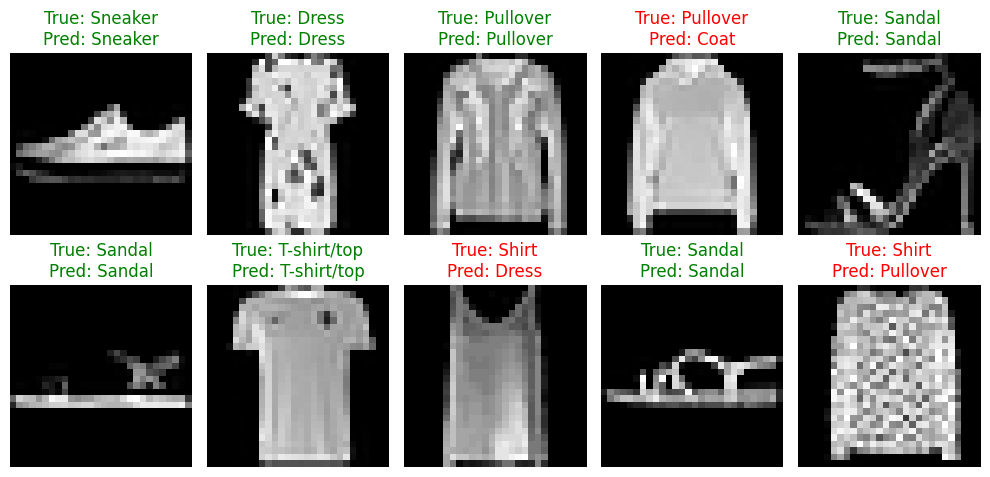

In [26]:
# Get model predictions
y_pred1 = model1.predict(x_test)  # Predict probabilities
y_pred1_classes = np.argmax(y_pred1, axis=1)  # Convert to class labels

num_images = 10  # Number of images to display
indices = np.random.choice(len(x_test), num_images, replace=False)

plt.figure(figsize=(10,5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)  # 2 rows, 5 columns
    plt.imshow(x_test[idx], cmap='gray')  # Show the test image
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred1_classes[idx]]}",
              color="green" if y_test[idx] == y_pred1_classes[idx] else "red")  # Green if correct, Red if wrong
    plt.axis("off")

plt.tight_layout()
plt.show()

###Second model( 2 hidden layer ANN)

In [11]:
#add 1 more layer with 'relu' activation function
model2= Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

In [12]:
#define optimizer
model2.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
#train 2nd model with 15 epochs
start_time = time.time()
history2 = model2.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test))
end_time = time.time()
training_time_model2 = end_time - start_time

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8777 - loss: 0.3394 - val_accuracy: 0.8613 - val_loss: 0.3899
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8830 - loss: 0.3297 - val_accuracy: 0.8655 - val_loss: 0.3783
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8819 - loss: 0.3257 - val_accuracy: 0.8680 - val_loss: 0.3777
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8854 - loss: 0.3212 - val_accuracy: 0.8680 - val_loss: 0.3755
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8859 - loss: 0.3176 - val_accuracy: 0.8649 - val_loss: 0.3808
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8866 - loss: 0.3131 - val_accuracy: 0.8696 - val_loss: 0.3710
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8878 - loss: 0.3095 - val_accuracy: 0.8677 - val_loss: 0.3750
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8886 - loss: 0.3100 - 

In [18]:
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)
print(f'Model-2 testing accuracy: {test_accuracy2*100:.2f}%')


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8715 - loss: 0.3706
Model-2 testing accuracy: 87.15%


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


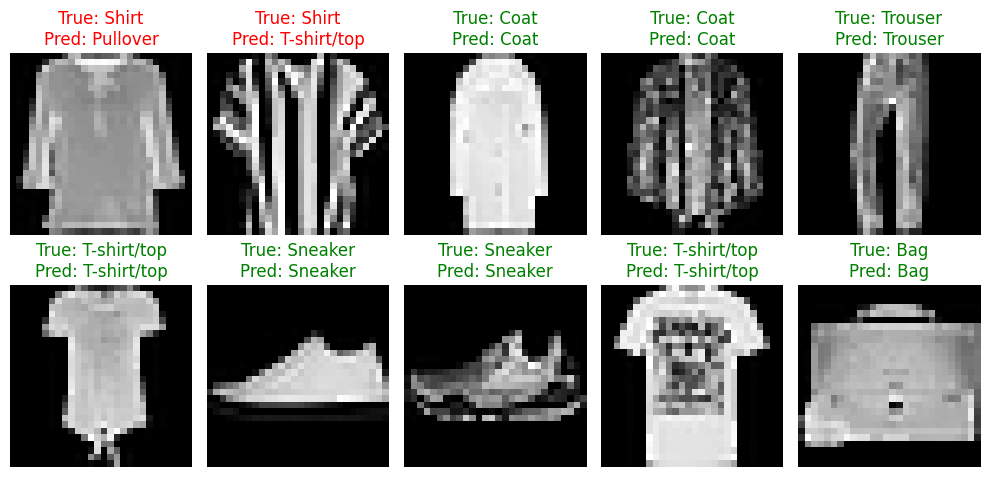

In [19]:
# Get model predictions
y_pred2 = model2.predict(x_test)  # Predict probabilities
y_pred2_classes = np.argmax(y_pred2, axis=1)  # Convert to class labels

num_images = 10  # Number of images to display
indices = np.random.choice(len(x_test), num_images, replace=False)

plt.figure(figsize=(10,5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)  # 2 rows, 5 columns
    plt.imshow(x_test[idx], cmap='gray')  # Show the test image
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred2_classes[idx]]}",
              color="green" if y_test[idx] == y_pred2_classes[idx] else "red")  # Green if correct, Red if wrong
    plt.axis("off")

plt.tight_layout()
plt.show()

###Third model( Support Vector Classifier)

In [20]:
#support vector classifier with 'rbf' kernel and 0.01 gamma
model3 = SVC(kernel="rbf",gamma=0.01)

#flatten picture
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

###Training 3rd model

In [21]:
start_time = time.time()
model3.fit(x_train_flat, y_train)
end_time = time.time()
training_time_model3 = end_time - start_time


#prediction
y_pred3 = model3.predict(x_test_flat)

#accruracy
accuracy = accuracy_score(y_test, y_pred3)
print(f"Model-3 testing accuracy: {accuracy:.2%}")

Model-3 testing accuracy: 88.26%


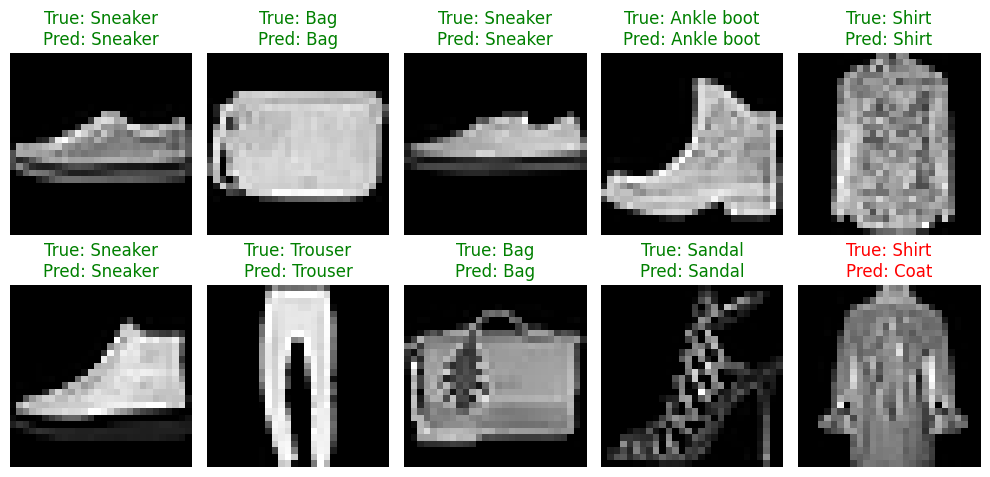

In [37]:
y_pred3_classes = y_pred3

# Select some test images for visualization
num_images = 10  # Number of images to display
indices = np.random.choice(len(x_test), num_images, replace=False)

# Plot images with predictions and ground truth labels
plt.figure(figsize=(10,5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)  # 2 rows, 5 columns
    plt.imshow(x_test[idx], cmap='gray')  # Show the test image
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred3_classes[idx]]}",
              color="green" if y_test[idx] == y_pred3_classes[idx] else "red")  # Green if correct, Red if wrong
    plt.axis("off")

plt.tight_layout()
plt.show()


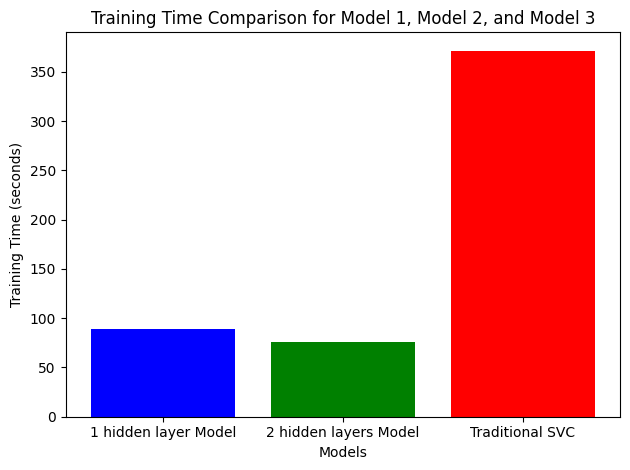

In [40]:
models = ['1 hidden layer Model', '2 hidden layers Model', 'Traditional SVC']
training_times = [training_time_model1, training_time_model2, training_time_model3]

plt.bar(models, training_times, color=['b', 'g', 'r'])

# Add labels and title
plt.xlabel('Models')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison for Model 1, Model 2, and Model 3')
plt.tight_layout()

# Show the plot
plt.show()